In [1]:
!pip install -q kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle (1).json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:05<00:00, 158MB/s]



In [4]:
!unzip microsoft-catsvsdogs-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/550.jpg   
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  

In [5]:
!kaggle datasets list -s cats


You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [6]:
!ls

 microsoft-catsvsdogs-dataset.zip   PetImages	     sample_data
'MSR-LA - 3467.docx'		   'readme[1].txt'


In [7]:
!ls PetImages

Cat  Dog


In [11]:
import os
file_names=os.listdir('/content/PetImages/Dog')
file_names

['474.jpg',
 '6783.jpg',
 '10910.jpg',
 '2228.jpg',
 '5425.jpg',
 '11894.jpg',
 '539.jpg',
 '10418.jpg',
 '10318.jpg',
 '7573.jpg',
 '278.jpg',
 '9031.jpg',
 '3073.jpg',
 '7972.jpg',
 '7770.jpg',
 '8610.jpg',
 '238.jpg',
 '6141.jpg',
 '2471.jpg',
 '634.jpg',
 '6938.jpg',
 '4796.jpg',
 '7133.jpg',
 '10407.jpg',
 '2960.jpg',
 '9887.jpg',
 '4415.jpg',
 '10929.jpg',
 '12424.jpg',
 '8704.jpg',
 '3141.jpg',
 '3253.jpg',
 '2028.jpg',
 '4083.jpg',
 '3145.jpg',
 '12384.jpg',
 '11453.jpg',
 '8146.jpg',
 '3589.jpg',
 '12263.jpg',
 '7178.jpg',
 '8742.jpg',
 '1093.jpg',
 '9278.jpg',
 '7462.jpg',
 '10699.jpg',
 '11095.jpg',
 '11775.jpg',
 '7293.jpg',
 '10444.jpg',
 '12059.jpg',
 '1276.jpg',
 '7118.jpg',
 '7331.jpg',
 '4336.jpg',
 '9520.jpg',
 '9352.jpg',
 '6672.jpg',
 '4504.jpg',
 '143.jpg',
 '6446.jpg',
 '6276.jpg',
 '3470.jpg',
 '5459.jpg',
 '3897.jpg',
 '2761.jpg',
 '2606.jpg',
 '6745.jpg',
 '696.jpg',
 '5657.jpg',
 '2164.jpg',
 '4525.jpg',
 '3102.jpg',
 '1628.jpg',
 '8147.jpg',
 '11717.jpg',
 '7

In [10]:
import numpy as np
import matplotlib.image as mpimg
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

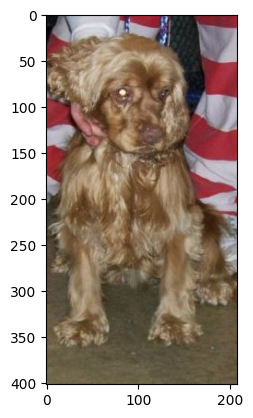

In [12]:
img=mpimg.imread('/content/PetImages/Dog/6321.jpg')
imgplt=plt.imshow(img)
plt.show()

In [14]:
import os

cat_count = len(os.listdir("PetImages/Cat"))
dog_count = len(os.listdir("PetImages/Dog"))

print("Number of Cat images:", cat_count)
print("Number of Dog images:", dog_count)

Number of Cat images: 12501
Number of Dog images: 12501


In [15]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/PetImages",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/PetImages",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [16]:
print(train_ds.class_names)

['Cat', 'Dog']


In [17]:
for images, labels in train_ds.take(1):
    print(labels)

tf.Tensor([0 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 0 0 1 1], shape=(32,), dtype=int32)


In [18]:
for images, labels in train_ds.take(1):
    images = images.numpy()
    labels = labels.numpy()

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


In [20]:
import os
import numpy as np
from PIL import Image

X = []
y = []

cat_path = "/content/PetImages/Cat"
dog_path = "/content/PetImages/Dog"

# First 1000 cats
for file in os.listdir(cat_path)[:1000]:
    try:
        img = Image.open(os.path.join(cat_path, file))
        img = img.convert('RGB')
        img = img.resize((224,224))
        X.append(np.asarray(img))
        y.append(0)      # Cat
    except:
        pass

# First 1000 dogs
for file in os.listdir(dog_path)[:1000]:
    try:
        img = Image.open(os.path.join(dog_path, file))
        img = img.convert('RGB')
        img = img.resize((224,224))
        X.append(np.asarray(img))
        y.append(1)      # Dog
    except:
        pass

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2000, 224, 224, 3)
(2000,)


In [21]:
#train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [22]:
print(X_train.shape,X_test.shape)

(1600, 224, 224, 3) (400, 224, 224, 3)


In [23]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [24]:
#building the nural neyrwork
#using the pretained model knwon mobilenet
import tensorflow as tf
import tensorflow_hub as hub


In [37]:
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=5,

)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8956 - loss: 0.2736
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9694 - loss: 0.0930
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9775 - loss: 0.0727
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9812 - loss: 0.0613
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9831 - loss: 0.0537


In [42]:
score,acc=model.evaluate(X_test_scaled,y_test)
print(score,acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9825 - loss: 0.0565
0.056548990309238434 0.9825000166893005


In [47]:
#buillding a predictive system
import cv2
input_image_path=input('path of the image to be predicted:')
input_image=cv2.imread(input_image_path)


input_image=cv2.resize(input_image,(224,224))
input_image=input_image/255
input_image=np.reshape(input_image,[1,224,224,3])
input_prediction=model.predict(input_image)
input_pred_label=np.argmax(input_prediction)
if input_pred_label==0:
  print("the input_image is a cat")
else:
  print("the input_image is a dog")



path of the image to be predicted:/content/cat.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
the input_image is a cat
